# 🔍 Módulo 1 — Exploración y estadística descriptiva

**Proyecto:** TinderJob 

---

### 📌 Punto de partida

La limpieza de datos ya está hecha por el equipo en `clean_tecnoempleo_data.py`.  
Este módulo parte del CSV limpio y se centra en:
- Inspeccionar la estructura y calidad del dataset procesado
- Detectar valores nulos y outliers con IQR
- Calcular estadísticos descriptivos de las variables clave
- Visualizar la distribución salarial

| Dataset | Archivo | Descripción |
|---|---|---|
| Tecnoempleo (limpio) | `clean_tecnoempleo_jobs.csv` | Dataset principal — scraping propio procesado |
| DS Salaries | `ds_salaries.csv` | Complementario — salarios globales data science |

---

## 0. Importaciones

In [3]:
# Importo las librerías necesarias para el análisis
# I import the necessary libraries for the analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuro el estilo visual de los gráficos
# I set the visual style for the charts
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14

## 1. Carga de datos

Leo el CSV ya limpio generado por `clean_tecnoempleo_data.py` de mi compañero.  
No repito la limpieza aquí — ese paso ya está documentado en `src/data_processing/`.

In [4]:
# Leo el dataset limpio generado por clean_tecnoempleo_data.py
# I read the clean dataset generated by clean_tecnoempleo_data.py
# IMPORTANTE: este archivo está en processed/, no en raw/
# IMPORTANT: this file is in processed/, not in raw/
df = pd.read_csv('../data/processed/clean_tecnoempleo_jobs.csv')

# Dataset complementario para análisis de salarios globales
# Complementary dataset for global salary analysis
df_sal = pd.read_csv('../data/ds_salaries.csv')
df_sal['salary_in_eur'] = df_sal['salary_in_usd'] * 0.92

# Recodifico niveles de experiencia con etiquetas legibles
# I recode experience levels with readable labels
nivel_exp_map = {
    'EN': 'Entry-level (Junior)',
    'MI': 'Mid-level (Semi-senior)',
    'SE': 'Senior',
    'EX': 'Executive / Director'
}
df_sal['experience_label'] = df_sal['experience_level'].map(nivel_exp_map)

print(f"Tecnoempleo (limpio): {df.shape[0]} ofertas, {df.shape[1]} columnas")
print(f"DS Salaries:          {df_sal.shape[0]} registros")
print(f"\nColumnas Tecnoempleo: {list(df.columns)}")

Tecnoempleo (limpio): 1148 ofertas, 13 columnas
DS Salaries:          607 registros

Columnas Tecnoempleo: ['titulo', 'empresa', 'ubicacion', 'salario', 'tipo_contrato', 'skills', 'busqueda', 'modalidad', 'ciudad', 'salario_min', 'salario_max', 'salario_medio', 'es_outlier']


## 2. Inspección inicial — `.shape`, `.dtypes`, `.describe()`

In [10]:
# Inspecciono la estructura general del dataset limpio
# I inspect the general structure of the clean dataset
print("=" * 60)
print("TECNOEMPLEO — DATASET LIMPIO")
print("=" * 60)
print(f"\nDimensiones (.shape): {df.shape}")
print("\nTipos de columnas (.dtypes):")
print(df.dtypes)
print("\nPrimeras filas (.head()):")
df.head(3)

TECNOEMPLEO — DATASET LIMPIO

Dimensiones (.shape): (1148, 13)

Tipos de columnas (.dtypes):
titulo               str
empresa              str
ubicacion            str
salario              str
tipo_contrato        str
skills               str
busqueda             str
modalidad            str
ciudad               str
salario_min      float64
salario_max      float64
salario_medio    float64
es_outlier          bool
dtype: object

Primeras filas (.head()):


,titulo,empresa,ubicacion,salario,tipo_contrato,skills,busqueda,modalidad,ciudad,salario_min,salario_max,salario_medio,es_outlier
0,rwe data scientist,sanofi,barcelona (híbrido),NaN,indefinido,"data, machine learning, deep learning",data-scientist,Híbrido,barcelona,NaN,NaN,NaN,False
1,analista programador/data scientist/bi,invoin,alcobendas - madrid (híbrido),NaN,indefinido,"nodejs, javascript, react",data-scientist,Híbrido,alcobendas - madrid,NaN,NaN,NaN,False
2,big data developer (fullstack - backend focus),talan,málaga - españa,NaN,indefinido,"big data, java, javascript",data-scientist,No especificado,málaga,NaN,NaN,NaN,False


In [ ]:
# Estadísticas descriptivas de las variables numéricas
# Descriptive statistics of numerical variables
print("Estadísticas descriptivas (.describe()):")
print(df.describe())

## 3. Valores nulos — `.isnull().sum()`

In [6]:
# Cuantifico los valores nulos por columna y su porcentaje
# I quantify null values per column and their percentage
nulos  = df.isnull().sum()
pct    = (nulos / len(df) * 100).round(1)
resumen_nulos = pd.DataFrame({'Nulos': nulos, '% del total': pct}).sort_values('Nulos', ascending=False)

print("VALORES NULOS — Tecnoempleo limpio")
print(resumen_nulos.to_string())

VALORES NULOS — Tecnoempleo limpio
               Nulos  % del total
salario          927         80.7
salario_medio    927         80.7
salario_min      927         80.7
salario_max      927         80.7
empresa            3          0.3
tipo_contrato      0          0.0
ubicacion          0          0.0
titulo             0          0.0
skills             0          0.0
ciudad             0          0.0
modalidad          0          0.0
busqueda           0          0.0
es_outlier         0          0.0


**📝 Decisión documentada — nulos:**

| Campo | Decisión | Justificación |
|---|---|---|
| `salario`, `salario_min`, `salario_max`, `salario_medio` | Conservar NaN | Tecnoempleo casi nunca publica salario en el listado. Es una limitación real del portal, no un error de limpieza |
| `skills` | Conservar NaN | No todas las ofertas etiquetan tecnologías requeridas |
| `modalidad` / `ciudad` | Conservar NaN | Algunas ofertas no especifican ubicación ni modalidad |

## 4. Detección de outliers — Método IQR

In [ ]:
# Función reutilizable para detectar outliers con el método IQR
# Reusable function to detect outliers using the IQR method
# Un valor es outlier si cae fuera de [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
# A value is an outlier if it falls outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
def detectar_outliers_iqr(df, columna):
    serie    = df[columna].dropna()
    Q1, Q3   = serie.quantile(0.25), serie.quantile(0.75)
    IQR      = Q3 - Q1
    lim_inf  = Q1 - 1.5 * IQR
    lim_sup  = Q3 + 1.5 * IQR
    outliers = serie[(serie < lim_inf) | (serie > lim_sup)]
    return {
        'Q1': round(Q1, 2), 'Q3': round(Q3, 2), 'IQR': round(IQR, 2),
        'Límite inferior': round(lim_inf, 2),
        'Límite superior': round(lim_sup, 2),
        'Nº outliers': len(outliers),
        '% outliers': round(len(outliers) / len(serie) * 100, 1)
    }

# Aplico IQR sobre las variables numéricas de salario (Tecnoempleo) y DS Salaries
# I apply IQR on salary numerical variables (Tecnoempleo) and DS Salaries
variables = {
    'salario_medio (Tecnoempleo)': (df,     'salario_medio'),
    'salary_in_eur (DS Salaries)': (df_sal, 'salary_in_eur'),
}

for nombre, (dataset, col) in variables.items():
    if col in dataset.columns and dataset[col].notna().sum() > 0:
        r = detectar_outliers_iqr(dataset, col)
        print(f"\n📌 {nombre}")
        for k, v in r.items():
            print(f"   {k:<22}: {v}")
    else:
        print(f"\n📌 {nombre} — sin datos numéricos suficientes")

**📝 Decisión documentada — outliers:**

| Variable | Decisión | Justificación |
|---|---|---|
| `salario_medio` | Conservar, usar **mediana** | Los salarios extremos son reales (roles ejecutivos). La distribución es asimétrica positiva |
| `salary_in_eur` (DS Salaries) | Conservar, recortar en gráficos | Outliers superiores = roles directivos o mercado USA. Se conservan en estadísticos y se recortan visualmente al percentil 95 |

## 5. Estadística descriptiva — Media, mediana y desviación estándar

Calculo los estadísticos principales de las variables numéricas más relevantes.

In [9]:
# Estadísticos descriptivos sobre Tecnoempleo
# Descriptive statistics on Tecnoempleo
print("=" * 60)
print("ESTADÍSTICA DESCRIPTIVA — TECNOEMPLEO (mercado español)")
print("=" * 60)

# Me concentro en las variables que tienen datos numéricos reales
# I focus on the variables that have real numerical data
vars_tec = {
    'salario_medio':  'Salario medio anual (€)',
    'salario_min':    'Salario mínimo (€)',
    'salario_max':    'Salario máximo (€)',
}

for col, etiqueta in vars_tec.items():
    if col in df.columns:
        serie = df[col].dropna()
        if len(serie) > 0:
            print(f"\n {etiqueta}")
            print(f"   Registros válidos : {len(serie):,} ({len(serie)/len(df)*100:.1f}%)")
            print(f"   Media             : {serie.mean():,.2f}")
            print(f"   Mediana           : {serie.median():,.2f}")
            print(f"   Desv. estándar    : {serie.std():,.2f}")
            print(f"   Mín / Máx         : {serie.min():,.0f} / {serie.max():,.0f}")
        else:
            print(f"\n {etiqueta} — sin datos (salario no publicado en Tecnoempleo)")

ESTADÍSTICA DESCRIPTIVA — TECNOEMPLEO (mercado español)

 Salario medio anual (€)
   Registros válidos : 221 (19.3%)
   Media             : 37,876.47
   Mediana           : 36,000.00
   Desv. estándar    : 12,431.18
   Mín / Máx         : 15,500 / 83,000

 Salario mínimo (€)
   Registros válidos : 221 (19.3%)
   Media             : 33,427.15
   Mediana           : 30,000.00
   Desv. estándar    : 11,136.96
   Mín / Máx         : 15,000 / 80,000

 Salario máximo (€)
   Registros válidos : 221 (19.3%)
   Media             : 42,325.79
   Mediana           : 39,000.00
   Desv. estándar    : 14,407.47
   Mín / Máx         : 16,000 / 86,000


In [11]:
# Estadísticos descriptivos sobre DS Salaries (dataset global complementario)
# Descriptive statistics on DS Salaries (global complementary dataset)
print("=" * 60)
print("ESTADÍSTICA DESCRIPTIVA — DS SALARIES (global)")
print("=" * 60)

orden_exp = ['Entry-level (Junior)', 'Mid-level (Semi-senior)', 'Senior', 'Executive / Director']

vars_sal = {
    'salary_in_eur': 'Salario anual convertido (EUR)',
    'remote_ratio':  'Ratio de trabajo remoto (%)'
}

for col, etiqueta in vars_sal.items():
    serie = df_sal[col].dropna()
    print(f"\n {etiqueta}")
    print(f"   Registros válidos : {len(serie):,}")
    print(f"   Media             : {serie.mean():,.2f}")
    print(f"   Mediana           : {serie.median():,.2f}")
    print(f"   Desv. estándar    : {serie.std():,.2f}")
    print(f"   Mín / Máx         : {serie.min():,.0f} / {serie.max():,.0f}")

ESTADÍSTICA DESCRIPTIVA — DS SALARIES (global)

📌 Salario anual convertido (EUR)
   Registros válidos : 607
   Media             : 103,314.04
   Mediana           : 93,444.40
   Desv. estándar    : 65,280.68
   Mín / Máx         : 2,630 / 552,000

📌 Ratio de trabajo remoto (%)
   Registros válidos : 607
   Media             : 70.92
   Mediana           : 100.00
   Desv. estándar    : 40.71
   Mín / Máx         : 0 / 100


**📝 Interpretación:** La brecha entre media (€103.314) y mediana (€93.444) confirma una distribución asimétrica positiva: unos pocos salarios muy altos elevan la media por encima del valor típico. La desviación estándar (€65.280) es muy alta — casi el 70% de la mediana — lo que indica que hay enorme variabilidad salarial en roles de datos. La mediana es el estadístico más honesto para comunicar el salario real a los candidatos de DataTalent.

## 6. Distribución de ofertas por término de búsqueda

Analizo qué perfiles tienen más demanda en el mercado español según Tecnoempleo.

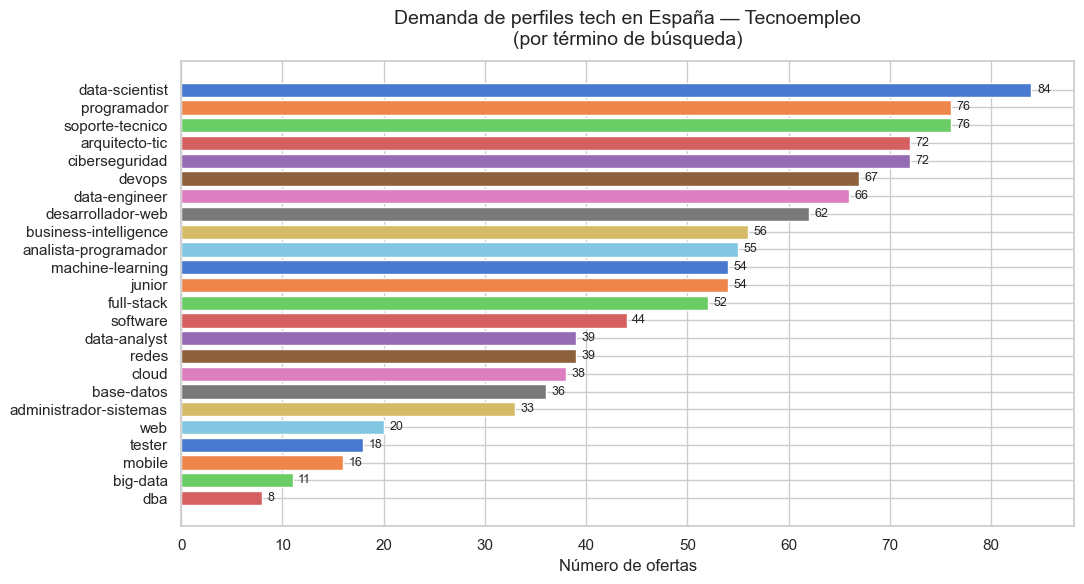

              busqueda  n_ofertas
        data-scientist         84
           programador         76
       soporte-tecnico         76
        arquitecto-tic         72
        ciberseguridad         72
                devops         67
         data-engineer         66
     desarrollador-web         62
 business-intelligence         56
  analista-programador         55
      machine-learning         54
                junior         54
            full-stack         52
              software         44
          data-analyst         39
                 redes         39
                 cloud         38
            base-datos         36
administrador-sistemas         33
                   web         20
                tester         18
                mobile         16
              big-data         11
                   dba          8


In [12]:
# Cuento las ofertas por término de búsqueda y ordeno de mayor a menor
# I count offers by search term and sort from highest to lowest
demanda = df['busqueda'].value_counts().reset_index()
demanda.columns = ['busqueda', 'n_ofertas']

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(
    demanda['busqueda'],
    demanda['n_ofertas'],
    color=sns.color_palette('muted', len(demanda))
)
ax.set_xlabel('Número de ofertas')
ax.set_title('Demanda de perfiles tech en España — Tecnoempleo\n(por término de búsqueda)', pad=12)
ax.bar_label(bars, padding=4, fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../data/processed/demanda_por_perfil.png', dpi=150, bbox_inches='tight')
plt.show()
print(demanda.to_string(index=False))

**📝 Interpretación:** Los perfiles con más demanda son data-scientist (84 ofertas), programador y soporte-técnico (76 cada uno). En el extremo opuesto, big-data (11) y dba (8) tienen muy poca presencia. Para DataTalent: los programas de reskilling deberían orientarse hacia los 5 perfiles con más demanda, donde los candidatos tienen más probabilidades de inserción laboral.

## 7. Distribución salarial — Histograma con curva KDE

Visualizo la distribución del salario para confirmar la asimetría y verificar si se aproxima a una distribución normal.


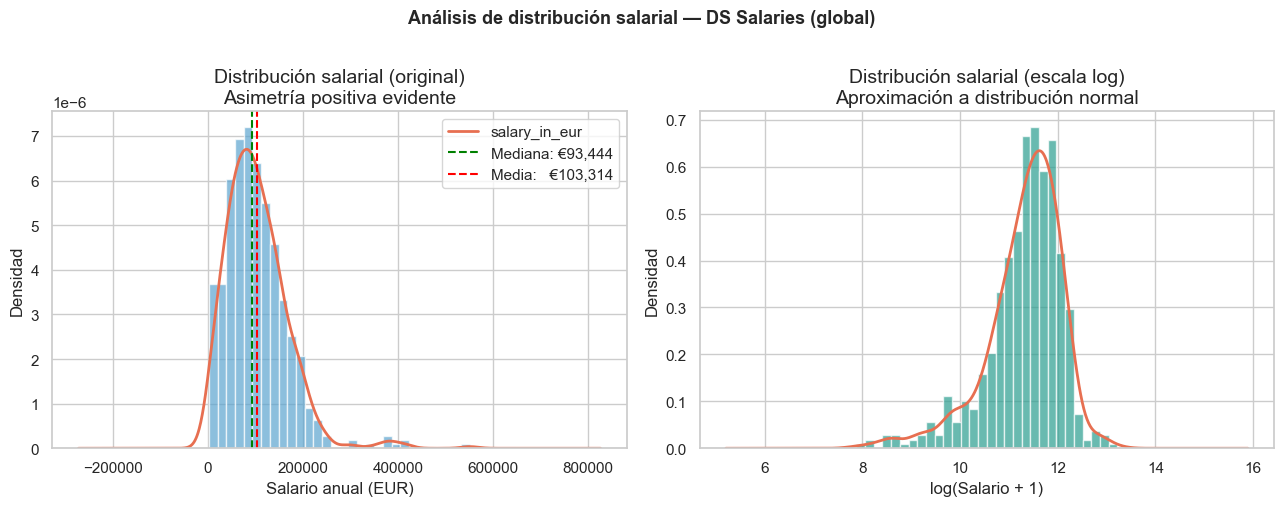


Test de normalidad Shapiro-Wilk (n=200):
  W = 0.9067 | p = 0.000000
  → NO sigue distribución normal (p < 0.05)


In [13]:
# Uso DS Salaries para la distribución salarial porque Tecnoempleo apenas publica salarios
# I use DS Salaries for salary distribution because Tecnoempleo rarely publishes salaries
salarios = df_sal['salary_in_eur'].dropna()
salarios_log = np.log1p(salarios)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribución original — muestra la asimetría positiva / Original distribution — shows positive skewness
axes[0].hist(salarios, bins=30, color='#5ba4cf', edgecolor='white', density=True, alpha=0.7)
salarios.plot.kde(ax=axes[0], color='#e76f51', linewidth=2)
axes[0].axvline(salarios.median(), color='green', linestyle='--', label=f'Mediana: €{salarios.median():,.0f}')
axes[0].axvline(salarios.mean(),   color='red',   linestyle='--', label=f'Media:   €{salarios.mean():,.0f}')
axes[0].set_title('Distribución salarial (original)\nAsimetría positiva evidente')
axes[0].set_xlabel('Salario anual (EUR)')
axes[0].set_ylabel('Densidad')
axes[0].legend()

# Transformación logarítmica — aproxima a distribución normal
# Logarithmic transformation — approximates normal distribution
axes[1].hist(salarios_log, bins=30, color='#2a9d8f', edgecolor='white', density=True, alpha=0.7)
salarios_log.plot.kde(ax=axes[1], color='#e76f51', linewidth=2)
axes[1].set_title('Distribución salarial (escala log)\nAproximación a distribución normal')
axes[1].set_xlabel('log(Salario + 1)')
axes[1].set_ylabel('Densidad')

plt.suptitle('Análisis de distribución salarial — DS Salaries (global)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/distribucion_salarial.png', dpi=150, bbox_inches='tight')
plt.show()

# Test de normalidad Shapiro-Wilk sobre muestra representativa
# Shapiro-Wilk normality test on a representative sample
muestra = salarios.sample(min(200, len(salarios)), random_state=42)
stat, p_val = stats.shapiro(muestra)
print(f"\nTest de normalidad Shapiro-Wilk (n={len(muestra)}):")
print(f"  W = {stat:.4f} | p = {p_val:.6f}")
print(f"  → {'NO sigue distribución normal (p < 0.05)' if p_val < 0.05 else 'Compatible con distribución normal'}")

**📝 Interpretación:** El test de Shapiro-Wilk confirma que el salario NO sigue una distribución normal (W=0.9067, p<0.05). La mediana (€93.444) está por debajo de la media (€103.314), lo que confirma la asimetría positiva: unos pocos salarios muy altos tiran de la media hacia arriba. La transformación logarítmica aproxima la distribución a la normalidad, lo que sería útil si en el futuro se aplica un modelo de regresión.

**Implicación para DataTalent:** usar la media salarial en los materiales de candidatos induciría expectativas erróneas. Siempre comunicar la **mediana** (€93.444) como referencia salarial.

---
**➡️ Siguiente módulo:** `analisis_02_correlaciones_agrupaciones_probabilidad.ipynb`